## Download and Clean

This section loads the dataset, handles duplicates,
and converts data types for downstream analysis.

In [1]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.calibration import calibration_curve
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
import pandas as pd
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb



warnings.filterwarnings('ignore')

# no hidden on columns and rows
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# # read the file
# df = pd.read_csv('/content/drive/MyDrive/python_and_UTS /2025_spring_UTS/Stat_As3/TeleCom_Data-2.csv', sep=';', header=None)

df = pd.read_csv('TeleCom_Data-2.csv', sep=';', header=None)

# split by ;
df_clean = df[0].str.split(";",expand=True)
df_clean = df_clean.replace('"', '', regex=True)
df_clean.columns = df_clean.iloc[0]
df = df_clean[1:]
df = df.copy()

In [3]:
# define categorical and numeric columns
cat_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
nu_columns = [ 'campaign', 'pdays' , 'previous',  'emp.var.rate', 'cons.price.idx',  'cons.conf.idx',   'euribor3m',   'nr.employed'  ]
all_columns = cat_columns + nu_columns

for i in nu_columns:
  df[i] = pd.to_numeric(df[i], errors = 'coerce')  # Convert to numeric and coerce invalid values to NaN

In [4]:
#clean dupli and missing value
duplicates = df.duplicated()
df = df.drop_duplicates()


# Replace
median_value = df[df['pdays'] != 999]['pdays'].median()                                       # count median from normal rows
df.loc[(df['poutcome'] != 'nonexistent') & (df['pdays'] == 999), 'pdays'] = 6       # if outcome is not 'nonexistent' and pdays is 999, then pdays = 6
df.loc[df['poutcome'] == 'nonexistent', 'pdays'] = -1    # no contact records, fill with -1


#  encode the target: no → 0, yes → 1
df['y'] = df['y'].replace({'no':0,'yes':1})

In [5]:
# check distribution of y
df['y'].value_counts(normalize=True)

y
0    0.887364
1    0.112636
Name: proportion, dtype: float64

In [6]:
# Cut age and duration

df['age'] = pd.to_numeric(df['age'], errors = 'coerce')
bins = [0,20, 30, 60,100]                                                             # set the bins and labels
labels = ['0-20', '20-30', '30-60', '60-100']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)   # cut age as age_group
cat_columns.append('age_group')    # add new feature into cat_columns list

df['duration'] = pd.to_numeric(df['duration'], errors='coerce')
bins = [0,10,30,60,180,999]                                                               # set the bins and label
labels = ['0-10','10-30','30-60','60-180','180+']
df['duration_group'] = pd.cut(df['duration'], bins=bins, labels=labels, right=True)        # cut duration, save it as duration_group

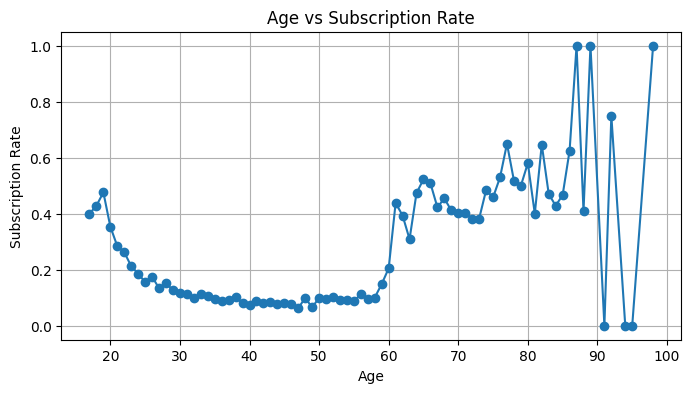

In [7]:
# The relationship of age and subscription rates
age_sub_rate = df.groupby('age')['y'].apply(lambda x: (x==1).mean())  # y=1, then calculate the mean
# or  can write: my_age = df[df['y']==1].groupby('age')['y'].mean()

# plot
plt.figure(figsize=(8, 4))
plt.plot(age_sub_rate.index, age_sub_rate.values, marker='o')
plt.xlabel('Age')
plt.ylabel('Subscription Rate')
plt.title('Age vs Subscription Rate')
plt.grid(True)
plt.show()

## Feature Engineer

Three new binary features were created to capture behavioral
and demographic patterns relevant to subscription likelihood:

- `young_uni`: clients aged 20–40 with a university or high school degree
- `has_previous_contact`: whether the client was contacted before this campaign
- `low_campaign`: whether the number of contacts in this campaign was 2 or fewer



In [8]:
df['young_uni'] = (
    (df['age'] >= 20) & (df['age'] <= 40) &
    (df['education'].isin(['university.degree','high.school']) )
).astype(int)


df['has_previous_contact'] = (df['previous'] > 0).astype(int)  #  multicollinearity problems ( after ohe) 0 1
df['low_campaign'] = (df['campaign'] <= 2).astype(int)  # 0 1

In [9]:
# create as a new list
binary_features = ['young_uni', 'has_previous_contact', 'low_campaign' ]

## Data splitting

- Remove unnecessary columns and define `y` as the target variable
- Drop `duration` and `duration_group` to prevent data leakage
- Split data stratified by `y` to ensure consistent class proportion across train, val, and test sets
- Apply One-Hot Encoding and scaling, then concatenate in order: binary → categorical → numerical
- Create `all_feature_names_final` following the same sequence to track column names after encoding


In [10]:
# set X and y
X = df.drop(columns=['y','duration', 'duration_group', 'age'])
y = df['y']

# data splitting, 0.3 for test, 0.35 for train and 0.35 for val.
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify= y)
X_train, X_val, y_train, y_val = train_test_split( X_temp, y_temp, test_size = 0.5, random_state = 42, stratify= y_temp)


# get binary columns
X_train_binary = X_train[binary_features]
X_test_binary = X_test[binary_features]
X_val_binary = X_val[binary_features]


# one hot encoding, fit on train, transform on val and test sets
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train[cat_columns])     # fit on train
X_test_cat = encoder.transform(X_test[cat_columns])       # transform on test
X_val_cat = encoder.transform(X_val[cat_columns])          # transform on val


# scaling, fit on train, transform on val and test sets
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[nu_columns])
X_test_num = scaler.transform(X_test[nu_columns])
X_val_num = scaler.transform(X_val[nu_columns])


# combine
X_train_final = np. concatenate([X_train_binary ,X_train_cat, X_train_num], axis=1)   # axis=1: concatenate along columns
X_test_final = np. concatenate([X_test_binary ,X_test_cat, X_test_num], axis=1)
X_val_final = np.concatenate([X_val_binary ,X_val_cat, X_val_num], axis=1)

In [11]:
# get feature names after encoding
cat_feature_names = encoder.get_feature_names_out(cat_columns)

# update list of various features
cat_feature_names_final = list(cat_feature_names) + list(binary_features)
binary_feature_names = list(binary_features)
nu_feature_names = list(nu_columns)
all_feature_names_final = binary_feature_names + list(cat_feature_names) + nu_feature_names

In [12]:
# set SMOTE and apply on train set
smote = SMOTE(sampling_strategy=0.35, random_state=42)     # default= 50% + 50%
X_train_smote, y_train_smote = smote.fit_resample(X_train_final, y_train)

# Baseline model

In [13]:
# create baseline model
dummy = DummyClassifier(strategy='most_frequent')   #
dummy.fit(X_train_final, y_train)

# predict
y_pred = dummy.predict(X_train_final)
y_pred_val = dummy.predict(X_val_final)

# report of best model on X_train
report = classification_report(y_train, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
0,0.89,1.00,0.94,12785.00
1,0.00,0.00,0.00,1623.00
accuracy,0.89,0.89,0.89,0.89
macro avg,0.44,0.50,0.47,14408.00
weighted avg,0.79,0.89,0.83,14408.00


In [14]:
# report of best model on X_train
report = classification_report(y_val, y_pred_val, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
0,0.89,1.00,0.94,12786.00
1,0.00,0.00,0.00,1623.00
accuracy,0.89,0.89,0.89,0.89
macro avg,0.44,0.50,0.47,14409.00
weighted avg,0.79,0.89,0.83,14409.00


# Train Machine Learning Model

## Set Hyperparameters

Logistic Regression

In [15]:
param_grid = {
    'C': [0.01, 0.1, 0.4, 1, 10],
    'max_iter': [100, 300, 500, 800],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid,
    scoring='f1',
    cv=5
)

LightGBM

In [16]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.08, 0.1],
    'scale_pos_weight': [3, 5, 8]
}

lgb_grid_search = GridSearchCV(
    lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [17]:
# SMOTE
lgbm_best_smote = lgb.LGBMClassifier(
            learning_rate= 0.05,
            max_depth= 5,
            n_estimators= 100,
             scale_pos_weight= 5
)

## Fit model

In [18]:
grid_search.fit(X_train_final, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [100, 300, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate 

In [19]:
lgb_grid_search.fit(X_train_final, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.08, ...], 'max_depth': [5, 7, ...], 'n_estimators': [100, 200, ...], 'scale_pos_weight': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [20]:
lgbm_best_smote.fit(X_train_smote, y_train_smote)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## Model Technical Performance


Preliminary model screening using **class 1 F1-score** as the primary metric.

Unlike accuracy or weighted F1, which are inflated by the majority class (y=0, 88.7%),
class 1 F1-score directly reflects the model's ability to identify subscribers —
the key objective of this project.



### Model Selection

In [21]:
# logistic
print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_)
print("Best model:", grid_search.best_estimator_)

# report of best model on X_train
logreg_best = grid_search.best_estimator_
y_pred = logreg_best.predict(X_val_final)

report = classification_report(y_val, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

Best params: {'C': 0.4, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1: 0.4554345957484152
Best model: LogisticRegression(C=0.4, class_weight='balanced', penalty='l1',
                   random_state=42, solver='liblinear')


,precision,recall,f1-score,support
0,0.95,0.86,0.90,12786.00
1,0.35,0.61,0.44,1623.00
accuracy,0.83,0.83,0.83,0.83
macro avg,0.65,0.73,0.67,14409.00
weighted avg,0.88,0.83,0.85,14409.00


In [22]:
# lgbm
print("Best params:", lgb_grid_search.best_params_)
print("Best F1:", lgb_grid_search.best_score_)
print("Best model:", lgb_grid_search.best_estimator_)

# report of best model on X_train
lgbm_best = lgb_grid_search.best_estimator_
y_pred = lgbm_best.predict(X_val_final)

report = classification_report(y_val, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'scale_pos_weight': 5}
Best F1: 0.5010773778544927
Best model: LGBMClassifier(learning_rate=0.05, max_depth=5, random_state=42,
               scale_pos_weight=5, verbose=-1)


,precision,recall,f1-score,support
0,0.94,0.91,0.92,12786.00
1,0.43,0.55,0.48,1623.00
accuracy,0.87,0.87,0.87,0.87
macro avg,0.69,0.73,0.70,14409.00
weighted avg,0.88,0.87,0.87,14409.00


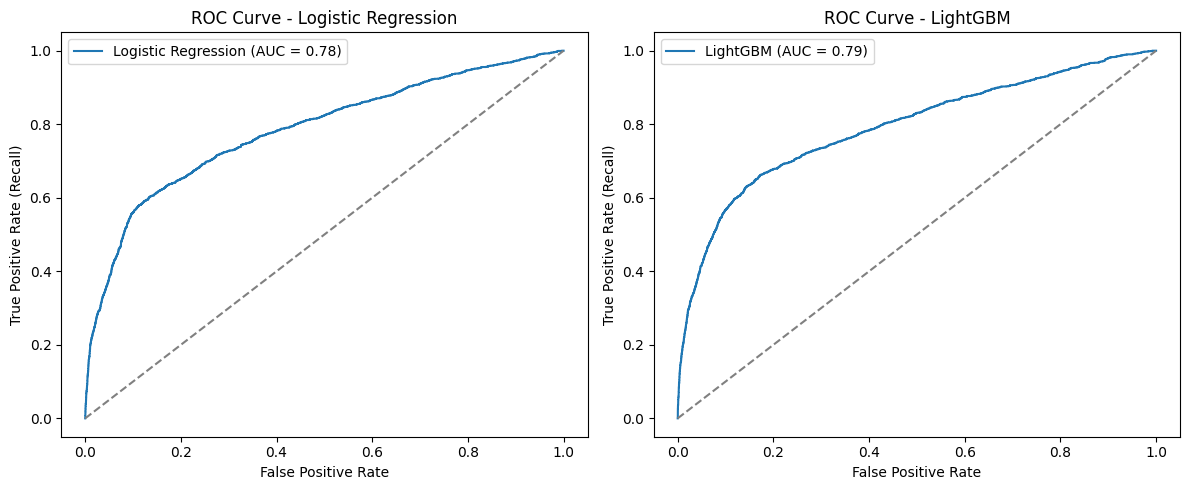

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot ROC for logreg
y_pred_proba_logreg = logreg_best.predict_proba(X_val_final)[:, 1]
fpr_logreg, tpr_logreg, _ = roc_curve(y_val, y_pred_proba_logreg)
auc_logreg = roc_auc_score(y_val, y_pred_proba_logreg)
ax1.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.2f})")
ax1.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.set_title("ROC Curve - Logistic Regression")
ax1.legend()

# Plot ROC for lgb_model_pa
y_pred_proba_lgbm = lgbm_best.predict_proba(X_val_final)[:, 1]
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_val, y_pred_proba_lgbm)
auc_lgbm = roc_auc_score(y_val, y_pred_proba_lgbm)
ax2.plot(fpr_lgbm, tpr_lgbm, label=f"LightGBM (AUC = {auc_lgbm:.2f})")
ax2.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate (Recall)")
ax2.set_title("ROC Curve - LightGBM")
ax2.legend()

plt.tight_layout()
plt.show()

In [24]:
# report of SMOTE lgbm
y_pred = lgbm_best_smote.predict(X_val_final)

report = classification_report(y_val, y_pred, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
0,0.94,0.88,0.91,12786.00
1,0.38,0.59,0.47,1623.00
accuracy,0.85,0.85,0.85,0.85
macro avg,0.66,0.74,0.69,14409.00
weighted avg,0.88,0.85,0.86,14409.00


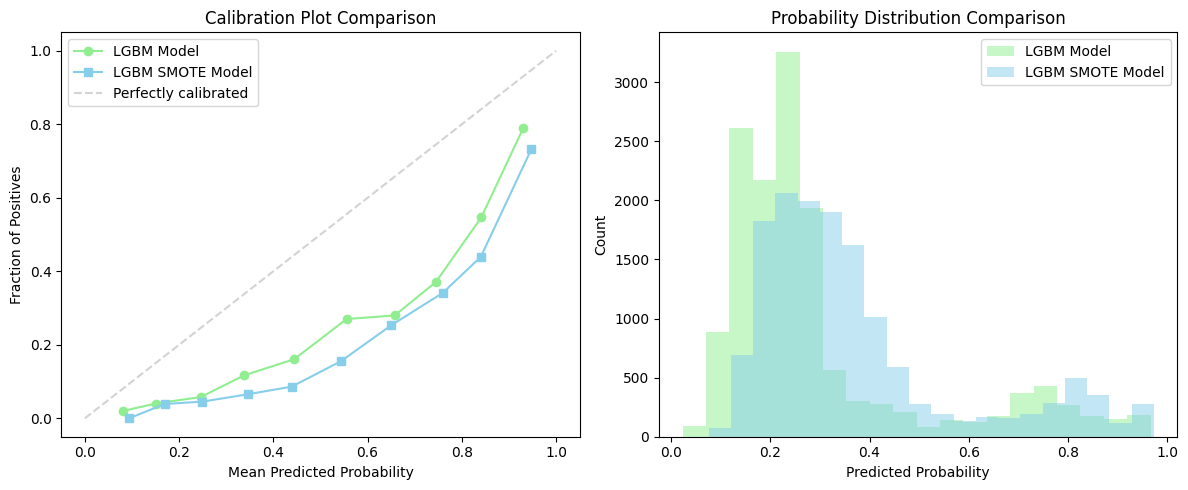

In [25]:
# baseline
y_prob_lgbm_best = lgbm_best.predict_proba(X_val_final)[:, 1]
prob_true1, prob_pred1 = calibration_curve(y_val, y_prob_lgbm_best, n_bins=10, strategy='uniform')

# SMOTE
y_prob_lgbm_best_smote = lgbm_best_smote.predict_proba(X_val_final)[:, 1]
prob_true2, prob_pred2 = calibration_curve(y_val, y_prob_lgbm_best_smote, n_bins=10, strategy='uniform')

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(prob_pred1, prob_true1, marker='o', label='LGBM Model', color='lightgreen')
ax1.plot(prob_pred2, prob_true2, marker='s', label='LGBM SMOTE Model', color='skyblue')
ax1.plot([0,1], [0,1], linestyle='--', color='lightgray', label='Perfectly calibrated')

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives')
ax1.set_title('Calibration Plot Comparison')
ax1.legend()

# plot
ax2.hist(y_prob_lgbm_best, bins=20, alpha=0.5, label='LGBM Model', color='lightgreen')
ax2.hist(y_prob_lgbm_best_smote, bins=20, alpha=0.5, label='LGBM SMOTE Model', color='skyblue')
ax2.set_xlabel('Predicted Probability')
ax2.set_ylabel('Count')
ax2.set_title('Probability Distribution Comparison')
ax2.legend()

plt.tight_layout()
plt.show()

**Insight:**
- **LightGBM selected** over Logistic Regression based on higher class 1 F1-score (0.48 vs 0.44) and ROC-AUC (0.79 vs 0.78)
- **Higher precision (0.43 vs 0.35):** LightGBM produces fewer false positives when predicting subscribers
- **Better calibration:** LightGBM baseline is closer to the diagonal than SMOTE model, indicating more reliable probability estimates
- **Conservative distribution:** LightGBM baseline concentrates predictions in lower probability range (0.1–0.4), reflecting the actual class imbalance (11%)
- **Baseline outperforms SMOTE** across all metrics — confirming `scale_pos_weight` is more effective than SMOTE for this dataset

### Threshold analysis

After LightGBM was selected as the best model, threshold analysis
is conducted to find the optimal classification threshold based
on the business objective of maximising campaign coverage
while controlling resource cost.

In [26]:
# print actual threshold, confusion matrix, and classification report

y_pred_05 = (y_prob_lgbm_best >= 0.5).astype(int)
report = classification_report(y_val, y_pred_05, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
0,0.94,0.91,0.92,12786.00
1,0.43,0.55,0.48,1623.00
accuracy,0.87,0.87,0.87,0.87
macro avg,0.69,0.73,0.70,14409.00
weighted avg,0.88,0.87,0.87,14409.00


In [27]:
# display precision, recall, and F1-score across multiple thresholds


print("Threshold   Precision   Recall   F1-score")
print("=" * 45)

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:   # compute y_pred_temp by thresholds
    y_pred_temp = (y_prob_lgbm_best >= threshold).astype(int)

    # count
    prec = precision_score(y_val, y_pred_temp)          # precision
    rec = recall_score(y_val, y_pred_temp)                   # recall
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0       # f1

    print(f"     {threshold:.1f}         {prec:.3f}           {rec:.3f}        {f1:.3f}")      # print results

Threshold   Precision   Recall   F1-score
     0.1         0.115           0.995        0.207
     0.2         0.154           0.877        0.262
     0.3         0.305           0.675        0.421
     0.4         0.377           0.603        0.464
     0.5         0.429           0.554        0.483
     0.6         0.450           0.513        0.479
     0.7         0.493           0.449        0.470
     0.8         0.641           0.263        0.373
     0.9         0.788           0.126        0.218
     0.9         0.879           0.018        0.035


In [28]:
# print actual threshold, confusion matrix, and classification report

y_pred_04 = (y_prob_lgbm_best >= 0.4).astype(int)
report = classification_report(y_val, y_pred_04, output_dict=True)
pd.DataFrame(report).transpose().round(2)

,precision,recall,f1-score,support
0,0.95,0.87,0.91,12786.00
1,0.38,0.60,0.46,1623.00
accuracy,0.84,0.84,0.84,0.84
macro avg,0.66,0.74,0.69,14409.00
weighted avg,0.88,0.84,0.86,14409.00


**Insight:**
- **Threshold = 0.4 is recommended:** captures over 60% of potential subscribers (Recall = 0.603) while maintaining acceptable precision (0.377), making it the best trade-off between campaign coverage and resource efficiency

In [29]:
import joblib

# save model and preprocessors
joblib.dump(lgbm_best, 'model.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# Business Analysis

From business aspect, analysis by the following step:
1.  Top 10% analysis: explore value clues from top 10% clients
2.  Define both high and low value segments
3.  Validation two segments, identify if it is really important
4.  Combine various groups with conditions from value segment, check the performanc

## Top 10% Analysis



1.   Analysis basic information of top 10% group
2.   Explore the subscription rates vary from top 10% to top 50%
3.   Compare the top 10% and entire customers under specific conditions by average subscription rates
4.   Plot it to visualize 



In [30]:
# top 10 data
top_10_threshold = np.percentile(y_prob_lgbm_best, 90)  # 90% = Top 10%
top_10_mask = y_prob_lgbm_best >= top_10_threshold
y_val_top10 = y_val[top_10_mask]

# print results
actual_subscription_rate = y_val_top10.mean()            # average subscription rates of top 10% customers
print(f"Top 10% customer's subscription rate: {actual_subscription_rate:.2%}")
print(f"Top 10% threshold prediction probability: {top_10_threshold:.3f}")
print(f"Sample size of Top 10%: {len(y_val_top10)}")
print(f"Proportion of Top 10%: {len(y_val_top10) / len(X_train_final) :.2%}")

Top 10% customer's subscription rate: 49.83%
Top 10% threshold prediction probability: 0.706
Sample size of Top 10%: 1441
Proportion of Top 10%: 10.00%


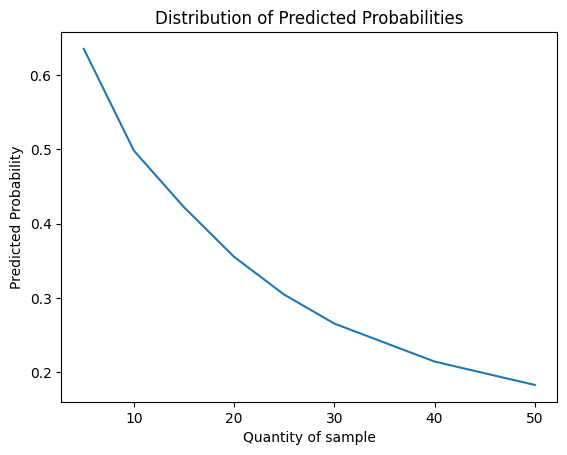

In [31]:
#  the subscription rates of the top X% customers, where X ranges from 5% to 50% of the total customer base.
#  e.g. the rates of top 10% is around 0.5, the rates of top 30% is lower than 0.3.

percentiles = [5, 10, 15, 20, 25, 30, 40, 50]
subscription_rates = []

for p in percentiles:
    threshold = np.percentile(y_prob_lgbm_best, 100-p)
    top_p_mask = y_prob_lgbm_best >= threshold
    rate = y_val[top_p_mask].mean()
    subscription_rates.append(rate)

# plot
plt.plot(percentiles, subscription_rates)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Quantity of sample')
plt.ylabel('Predicted Probability')
plt.show()

In [32]:
def compute_top10_diff(X_val_final, model, cat_features, threshold=0.10):
    """
    1. Compute the probability of val test from specific model.
    2. Count avg probability of both top 10% and all customers
    3. Identify features with specific threshold
    """

    # get proba of val set
    y_pred = model.predict_proba(X_val_final)[:, 1]
    top10_threshold = np.percentile(y_pred, 90)         # set threshold = 0.9 (top 10%)
    top10_mask = y_pred >= top10_threshold             # select rows by the threshold

    X_val_df = pd.DataFrame(X_val_final, columns=all_feature_names_final)
    X_top10_df = X_val_df[top10_mask]

    # empty list for store results
    rows = []

    # count avg probability of both top 10% and all customers, then idenfity them by specific threshold
    for col in cat_features:
        top10_pct = X_top10_df[col].mean()
        overall_pct = X_val_df[col].mean()
        diff = top10_pct - overall_pct

        if abs(diff) > threshold:         # leave rows reach the threshold (both + and -)
            rows.append({
                "feature": col,
                "top10": top10_pct,
                "overall": overall_pct,
                "diff": diff
            })

    df = pd.DataFrame(rows)
    return df.sort_values("diff", key=abs, ascending=False)

In [33]:
# show the feature difference
df_result = compute_top10_diff(X_val_final, lgbm_best, cat_feature_names, threshold=0.10)
df_result

,feature,top10,overall,diff
10,poutcome_nonexistent,0.538515,0.862169,-0.323655
6,contact_cellular,0.933380,0.637518,0.295861
7,contact_telephone,0.066620,0.362482,-0.295861
8,month_may,0.043026,0.333611,-0.290585
11,poutcome_success,0.291464,0.035117,0.256347
12,age_group_30-60,0.577377,0.798945,-0.221568
4,default_no,0.973629,0.790339,0.183290
5,default_unknown,0.026371,0.209522,-0.183151
0,job_blue-collar,0.061069,0.222292,-0.161223
13,age_group_60-100,0.155448,0.020959,0.134488


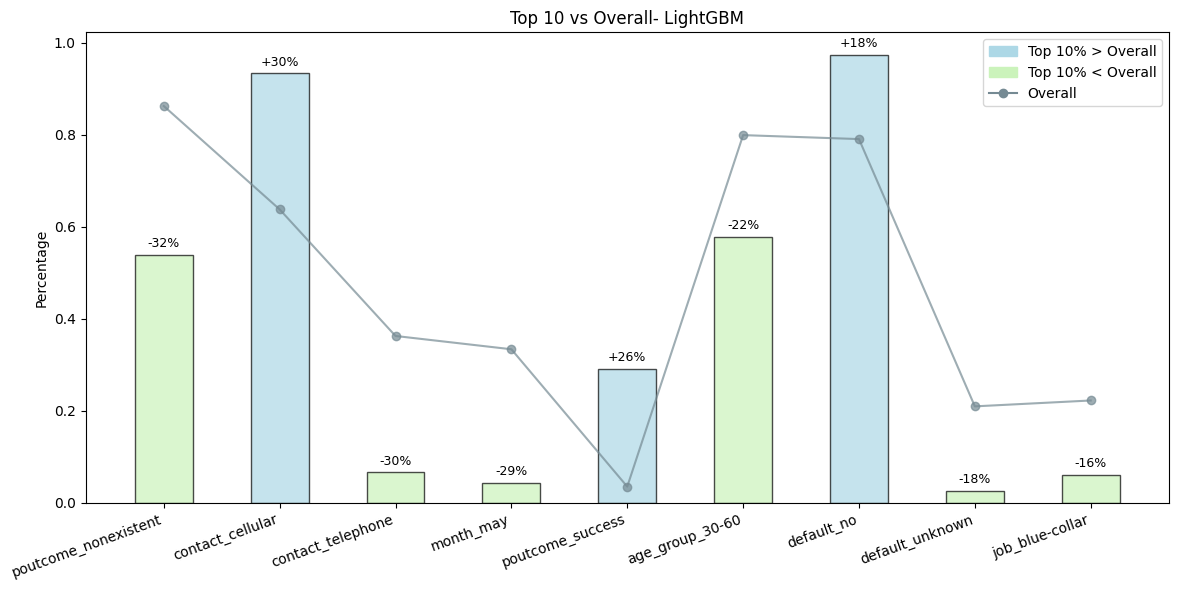

In [34]:
# the avg of entire dataset vs. top 10% dataset


# select features with |diff| > 0.14 (meaningful difference worth analyzing)
df_plot = compute_top10_diff(X_val_final, lgbm_best, cat_feature_names, threshold=0.14)

# set colors under conditions
colors = ["lightblue" if t > o else "#CBF3BB"
          for t, o in zip(df_plot["top10"], df_plot["overall"])]

# avg of top 10% dataset
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(df_plot["feature"], df_plot["top10"], color=colors, label="Top 10%", width=0.5, alpha=0.7, edgecolor='black')
ax1.plot(df_plot["feature"], df_plot["overall"], color="#758A93", marker="o", label="Overall",  alpha=0.7)

# the avg of entire dataset
for i, (t, o) in enumerate(zip(df_plot["top10"], df_plot["overall"])):
    diff = t - o
    ax1.text(i, t + 0.01, f"{diff:+.0%}", ha="center", va="bottom", fontsize=9)

# legend patches
pos_patch = mpatches.Patch(color="lightblue", label="Top 10% > Overall")
neg_patch = mpatches.Patch(color="#CBF3BB", label="Top 10% < Overall")
line_patch = Line2D([], [], color="#758A93", marker="o", label="Overall")


ax1.set_ylabel("Percentage")
ax1.set_xticklabels(df_plot["feature"], rotation=20, ha="right")
ax1.set_title("Top 10 vs Overall- LightGBM")
ax1.legend(handles=[pos_patch, neg_patch, line_patch])
plt.tight_layout()
plt.savefig('Top 10 vs Overall- LightGBM.png', dpi=450)
plt.show()

**Insight:**
- **Top 10% segment:** subscription rate of 49.93% — 4.5x higher than overall average (11%), confirming strong predictive power of the model
- **Diminishing returns:** expanding to top 20% drops subscription rate to 35% — 
  top 10% remains the most cost-effective targeting range
- **contact_cellular (+30%):** top 10% customers are far more reachable via cellular — **prioritise cellular over telephone in campaigns**
- **poutcome_success (+26%):** past campaign success is the strongest predictor — **re-engage previous subscribers first**
- **default_no (+18%):** clean credit history signals higher willingness to subscribe — **filter out unknown/default customers early**
- **poutcome_nonexistent (-32%), month_may (-29%):** first-time contacts and May campaigns yield poor results — **avoid cold outreach in May**
- **job_blue-collar (-16%), default_unknown (-18%):** consistently low engagement — **deprioritise these segments to reduce wasted resources**


## Segment Definition

Define high-value and low-value segments based on the results of top 10% analysis.

In [35]:
# define high-value customer
group1 = df[
            (df['default']=='no')&
            (df['education']=='university.degree')&
            (df['poutcome']=='success')
]        # Q=521, sub_rate = 0.3330

# low-value customer
bad_group1 = df[
    (df['job']=='blue-collar')&
    (df['default']=='unknown')
]


print(f' High-Value Segment (university degree + no default + previous success)')
print(f'Sample size: {group1.shape[0]}')
print(f'Subscription rate: {group1["y"].mean():.1%}')
print(f'Proportion of all dataset:{group1.shape[0] / df.shape[0]:.1%} ')

print(f'\n Low-Value Segment (blue-collar + unknown default)')
print(f'Sample size: {bad_group1.shape[0]}')
print(f'Subscription rate: {bad_group1["y"].mean():.1%}')
print(f'Proportion of all dataset:{bad_group1.shape[0] / df.shape[0]:.1%} ')

 High-Value Segment (university degree + no default + previous success)
Sample size: 521
Subscription rate: 66.6%
Proportion of all dataset:1.3% 

 Low-Value Segment (blue-collar + unknown default)
Sample size: 3166
Subscription rate: 4.8%
Proportion of all dataset:7.7% 


**Insights:**

- **High-value (1.3% of data):** subscription rate 66.6% — 6x overall average
- **Low-value (7.7% of data):** subscription rate only 4.8%
- Campaign resources should prioritize the high‑value segment. Even though it represents only about 1% of the population, it delivers the highest ROI.


## Validation - High Value

In [36]:
# get distribution
group1_condition = (
            (df['default']=='no')&
            (df['education']=='university.degree')&
            (df['poutcome']=='success')
)
group1 = group1[group1_condition]
print(f'group1')
print(group1['y'].value_counts(),'\n','-'*30)

group1_others = df[~group1_condition]
print(group1_others['y'].value_counts())

group1
y
1    347
0    174
Name: count, dtype: int64 
 ------------------------------
y
0    36357
1     4290
Name: count, dtype: int64


In [37]:
# Contingency table: subscription counts for high-value segment vs rest of population
data = pd.DataFrame({
    'y=0':[174, 36357 ],    # high-value, others
    'y=1':[347, 4290]        #  high-value, others
}, index = ['mateched 3 condition', 'other customers']
)

# compute metrics
chi2, p, dof, expected = chi2_contingency(data)

# print the results
print("Chi-square:", chi2)
print("p-value:", p)
print("df:", dof)
print("expected values table:\n", expected)

Chi-square: 1611.1879122994117
p-value: 0.0
df: 1
expected values table:
 [[  462.31662942    58.68337058]
 [36068.68337058  4578.31662942]]


In [38]:
# Contingency table: subscription counts for high-value segment vs rest of population
data = pd.DataFrame({
    'y=0':[174, 36357 ],    # high-value, others
    'y=1':[347, 4290]        #  high-value, others
}, index = ['mateched 3 condition', 'other customers']
)

# compute metrics
chi2, p, dof, expected = chi2_contingency(data)

# print the results
print("Chi-square:", chi2)
print("p-value:", p)
print("df:", dof)
print("expected values table:\n", expected)

Chi-square: 1611.1879122994117
p-value: 0.0
df: 1
expected values table:
 [[  462.31662942    58.68337058]
 [36068.68337058  4578.31662942]]


In [39]:
# compute Odds Ratio and Relative Risk

a, b = 347, 174
c, d = 4290, 36357

# Odds Ratio
OR = (a*d) / (b*c)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_log_or = [np.log(OR) - 1.96*se_log_or, np.log(OR) + 1.96*se_log_or]
ci_or = np.exp(ci_log_or)

# Relative Risk
risk_exposed = a / (a+b)
risk_control = c / (c+d)
RR = risk_exposed / risk_control
se_log_rr = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
ci_log_rr = [np.log(RR) - 1.96*se_log_rr, np.log(RR) + 1.96*se_log_rr]
ci_rr = np.exp(ci_log_rr)

print("Odds Ratio:", OR, "95% CI:", ci_or)
print("Relative Risk:", RR, "95% CI:", ci_rr)

Odds Ratio: 16.90094445784101 95% CI: [14.04928901 20.33141487]
Relative Risk: 6.31048816826168 95% CI: [5.90112681 6.74824694]


In [40]:
# new feature, 0=not match, 1=match
df["triple_condition_flag"] = (
    (df["default"]=="no") &
    (df["education"]=="university.degree") &
    (df["poutcome"]=="success")
).astype(int)

y = df["y"]
X = sm.add_constant(df["triple_condition_flag"])   # a column for intercept

# validate statistical significance of triple_condition_flag
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.340889
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41168
Model:                          Logit   Df Residuals:                    41166
Method:                           MLE   Df Model:                            1
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                 0.03154
Time:                        17:00:43   Log-Likelihood:                -14034.
converged:                       True   LL-Null:                       -14491.
Covariance Type:            nonrobust   LLR p-value:                8.280e-201
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.1371      0.016   -132.383      0.000      -2.169      -2.

**Insight:**
- **Chi-square (χ²=1611.19, p<0.001):** strong association between
  triple condition and subscription — not by chance
- **Odds Ratio=16.9:** high-value customers are 16.9x more likely
  to subscribe than others
- **Logistic Regression (β=2.83, p<0.001):** triple_condition_flag
  is statistically significant — confirms high-value segment definition

## Validation - Low Value

To ensure the low-value segment's poor performance is statistically
reliable and not due to chance, four tests were applied:

1. **Z-test:** single group test — directly checks if 4.8% is
   significantly below the overall average (11%)
2. **Chi-square:** two group comparison — checks if the difference
   between low-value and others is statistically significant
3. **Odds Ratio & Relative Risk:** quantifies *how much less likely*
   low-value customers are to subscribe compared to others
4. **Logistic Regression:** controls for other variables to confirm
   double_condition_flag independently predicts lower subscription

In [41]:
bad_group1_condition = (
            (df['job']=='blue-collar')&
            (df['default']=='unknown')       )
bad_group1 = df[bad_group1_condition]

print(f'bad_group1')
print(bad_group1['y'].value_counts(),'\n','-'*30)

print('Other groups')
bad_group1_others = df[~bad_group1_condition]
print(bad_group1_others['y'].value_counts())

bad_group1
y
0    3014
1     152
Name: count, dtype: int64 
 ------------------------------
Other groups
y
0    33517
1     4485
Name: count, dtype: int64


In [42]:
# One-Sample proportion test

count = 152
nobs = 3166
pop_rate = 0.11

stat, pval = proportions_ztest(count, nobs, value=pop_rate, alternative="smaller")
print("Z-stat:", stat, "p-value:", pval)

Z-stat: -16.315253715512906 p-value: 3.844303954125126e-60


In [43]:
data = pd.DataFrame({
    'y=0':[3014, 35517 ],
    'y=1':[152, 4485]
}, index = ['mateched 3 condition', 'other customers']
)

chi2, p, dof, expected = chi2_contingency(data)

print("Chi-square:", chi2)
print("p-value:", p)
print("df:", dof)
print("expected values table:\n", expected)

Chi-square: 125.09413124076355
p-value: 4.853680516526685e-29
df: 1
expected values table:
 [[ 2825.91609526   340.08390474]
 [35705.08390474  4296.91609526]]


In [44]:
a, b = 152, 3014
c, d = 4485, 35517

# Odds Ratio
OR = (a*d) / (b*c)
se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
ci_log_or = [np.log(OR) - 1.96*se_log_or, np.log(OR) + 1.96*se_log_or]
ci_or = np.exp(ci_log_or)

# Relative Risk
risk_exposed = a / (a+b)
risk_control = c / (c+d)
RR = risk_exposed / risk_control
se_log_rr = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
ci_log_rr = [np.log(RR) - 1.96*se_log_rr, np.log(RR) + 1.96*se_log_rr]
ci_rr = np.exp(ci_log_rr)

print("Odds Ratio:", OR, "95% CI:", ci_or)
print("Relative Risk:", RR, "95% CI:", ci_rr)

Odds Ratio: 0.3993688317395077 95% CI: [0.33832772 0.47142298]
Relative Risk: 0.4282051986300936 95% CI: [0.36578888 0.50127192]


In [45]:
df["double_condition_flag"] = (
    (df["job"]=="blue-collar") &
    (df["default"]=="unknown")
).astype(int)

y = df["y"]
X = sm.add_constant(df["double_condition_flag"])

model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.349861
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41168
Model:                          Logit   Df Residuals:                    41166
Method:                           MLE   Df Model:                            1
Date:                Sun, 07 Jun 2026   Pseudo R-squ.:                0.006052
Time:                        17:00:43   Log-Likelihood:                -14403.
converged:                       True   LL-Null:                       -14491.
Covariance Type:            nonrobust   LLR p-value:                 4.897e-40
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.0113      0.016   -126.500      0.000      -2.042      -1.

**Insight:**
- **Z-test (p<0.001):** low-value subscription rate (4.8%) is
  significantly lower than overall average (11%)
- **Chi-square (χ²=125.09, p<0.001):** confirms low-value segment
  has significantly fewer subscribers than expected
- Both tests consistently suggest this group should be deprioritised
  in marketing campaigns

## Simulation

To provide actionable marketing recommendations, this section simulates
subscription rates of both segments under different contact channels
(cellular, telephone) and months (March, May, October) and their combinations,
to identify the most effective conditions for reaching high-value customers.

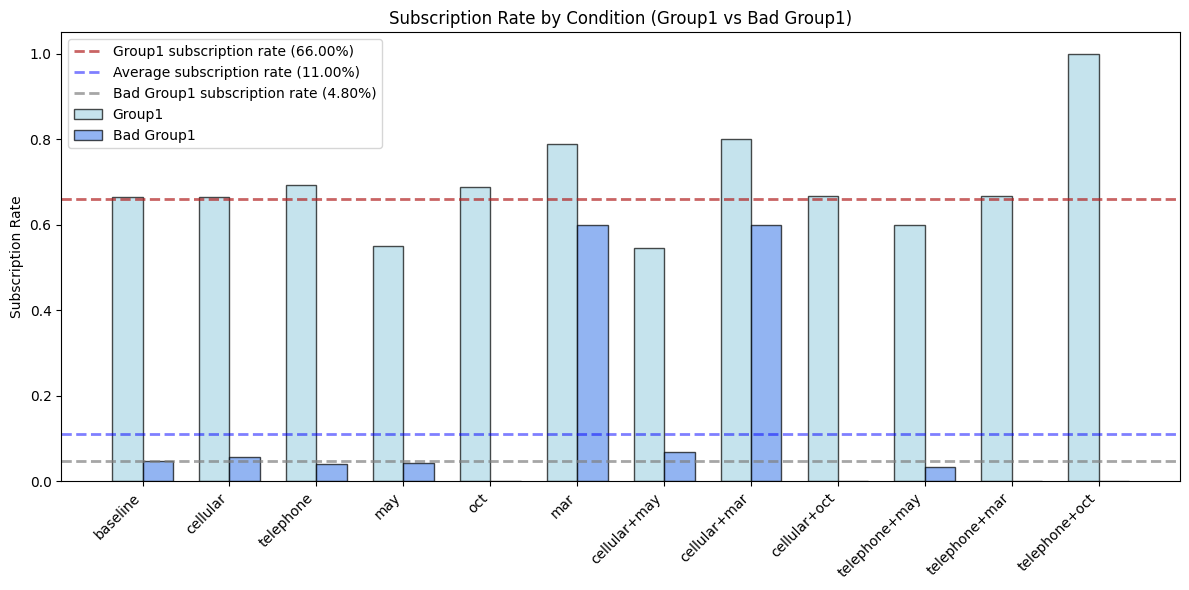

        Condition  Group1_rate  Group1_n  BadGroup1_rate  BadGroup1_n
0        baseline     0.666027       521        0.048010         3166
1        cellular     0.663900       482        0.057510         1478
2       telephone     0.692308        39        0.039692         1688
3             may     0.550000        60        0.043806         1461
4             oct     0.688889        45        0.000000            0
5             mar     0.787879        33        0.600000            5
6    cellular+may     0.545455        55        0.068584          452
7    cellular+mar     0.800000        30        0.600000            5
8    cellular+oct     0.666667        42        0.000000            0
9   telephone+may     0.600000         5        0.032706         1009
10  telephone+mar     0.666667         3        0.000000            0
11  telephone+oct     1.000000         3        0.000000            0


In [46]:
# subscription rates of two groups
sub_rate_group1_baseline = len(group1[group1['y']==1]) / len(group1)
sub_rate_bad_group1_baseline = len(bad_group1[bad_group1['y']==1]) / len(bad_group1)

# one condition
con_cell = (df['contact'] == 'cellular')
con_tele = (df['contact'] == 'telephone')
mon_may = (df['month'] == 'may')
mon_oct = (df['month'] == 'oct')
mon_mar = (df['month'] == 'mar')

# combination condition
cell_may = con_cell & mon_may
cell_mar = con_cell & mon_mar
cell_oct = con_cell & mon_oct
tele_may = con_tele & mon_may
tele_mar = con_tele & mon_mar
tele_oct = con_tele & mon_oct

condition_list = [
    con_cell, con_tele, mon_may, mon_oct, mon_mar,
    cell_may, cell_mar, cell_oct,
    tele_may, tele_mar, tele_oct
]

condition_labels = [
    'baseline',
    'cellular', 'telephone', 'may', 'oct', 'mar',
    'cellular+may', 'cellular+mar', 'cellular+oct',
    'telephone+may', 'telephone+mar', 'telephone+oct'
]

# baseline rates
sub_rate_group1 = [sub_rate_group1_baseline]
sub_rate_bad_group1 = [sub_rate_bad_group1_baseline]
n_group1 = [len(group1)]
n_bad_group1 = [len(bad_group1)]

# calculate the sample size and subscription under each scenario
for cond in condition_list:

    # group1
    g1 = group1[cond]
    rate1 = len(g1[g1['y']==1]) / len(g1) if len(g1) > 0 else 0   # compute subscription rate, if rows = 0, then rate = 0
    sub_rate_group1.append(rate1)
    n_group1.append(len(g1))

    # bad_group1
    g2 = bad_group1[cond]
    rate2 = len(g2[g2['y']==1]) / len(g2) if len(g2) > 0 else 0
    sub_rate_bad_group1.append(rate2)
    n_bad_group1.append(len(g2))

# plot
x = np.arange(len(condition_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width/2, sub_rate_group1, width, label='Group1', color= 'lightblue', alpha=0.7, edgecolor='black')
ax.bar(x + width/2, sub_rate_bad_group1, width, label='Bad Group1', color='cornflowerblue', alpha=0.7, edgecolor='black')

ax.axhline(0.66, color='firebrick', linestyle='--', alpha=0.7, linewidth=2,
           label=f'Group1 subscription rate ({0.66:.2%})')
ax.axhline(0.11, color='blue', linestyle='--', alpha=0.5, linewidth=2,
           label=f'Average subscription rate ({0.11:.2%})')
ax.axhline(0.048, color='gray', linestyle='--', alpha=0.7, linewidth=2,
           label=f'Bad Group1 subscription rate ({0.048:.2%})')

ax.set_ylabel('Subscription Rate')
ax.set_title('Subscription Rate by Condition (Group1 vs Bad Group1)')
ax.set_xticks(x)
ax.set_xticklabels(condition_labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

# output table
result_df = pd.DataFrame({
    'Condition': ['baseline'] + condition_labels[1:],
    'Group1_rate': sub_rate_group1,
    'Group1_n': n_group1,
    'BadGroup1_rate': sub_rate_bad_group1,
    'BadGroup1_n': n_bad_group1
})

print(result_df)

**Insight:**


- **The best scenarios:** March (79%) and cellular+Mar (80%)  significantly outperform baseline (66%)
- **telephone+oct (100%):** extreme result but sample size is only 3 —
  not reliable, should not be generalised
- **May underperforms:** subscription rate drops to 55% for high-value group,
  suggesting campaigns should avoid this month
- **Low-value group:** remains consistently low across all scenarios (~4-6%),  except March-related conditions — but sample sizes are too small (<5) to be conclusive
- **Key recommendation:** prioritise cellular contact in March for high-value customers
  to maximise subscription rate